# 🤖 ML-Based Zone Classification with K-Means & Random Forest

**Purpose:** Train a machine learning model to classify urban zones as Office, Residential, or Leisure based on POI features and traffic patterns.

**Workflow:**
1. Fetch POI data using TomTom API
2. Apply K-Means clustering to create zones
3. Engineer features (POI counts, traffic metrics)
4. Train Random Forest classifier
5. Evaluate model performance
6. Visualize results

---

In [49]:
# Import required libraries
import requests
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import folium
from folium import plugins
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [50]:
# Configuration
TOMTOM_API_KEY = "X47KFIvPV5LB2FKHlVI7zIdaOU3GoUQ9"

# Multiple test areas for diverse training data - EXPANDED DATASET
TRAINING_AREAS = [
    # Office zones
    {"name": "Pune IT Park", "lat": 18.5204, "lon": 73.8567, "expected_type": "Office"},
    {"name": "Hinjewadi Tech Hub", "lat": 18.5913, "lon": 73.7389, "expected_type": "Office"},
    {"name": "Kharadi IT Park", "lat": 18.5515, "lon": 73.9475, "expected_type": "Office"},
    {"name": "Magarpatta City", "lat": 18.5157, "lon": 73.9294, "expected_type": "Office"},
    
    # Residential zones
    {"name": "Koregaon Park Residential", "lat": 18.5362, "lon": 73.8958, "expected_type": "Residential"},
    {"name": "Baner Residential", "lat": 18.5590, "lon": 73.7789, "expected_type": "Residential"},
    {"name": "Aundh Residential", "lat": 18.5642, "lon": 73.8077, "expected_type": "Residential"},
    {"name": "Kalyani Nagar", "lat": 18.5484, "lon": 73.9062, "expected_type": "Residential"},
    
    # Leisure zones
    {"name": "FC Road Shopping", "lat": 18.5314, "lon": 73.8446, "expected_type": "Leisure"},
    {"name": "Camp Leisure Zone", "lat": 18.5196, "lon": 73.8553, "expected_type": "Leisure"},
    {"name": "Phoenix Market City", "lat": 18.5626, "lon": 73.9146, "expected_type": "Leisure"},
    {"name": "Koregaon Park Cafes", "lat": 18.5379, "lon": 73.8922, "expected_type": "Leisure"},
]

SEARCH_RADIUS_METERS = 1000  

print(f"🎯 Configured {len(TRAINING_AREAS)} training areas")
print(f"📍 Search radius: {SEARCH_RADIUS_METERS}m")


🎯 Configured 12 training areas
📍 Search radius: 1000m


In [51]:
# Fetch POIs from TomTom API
def fetch_pois_nearby(lat, lon, api_key, radius=1000, limit=100):
    """Fetch POIs around a coordinate using TomTom's Nearby Search API"""
    url = "https://api.tomtom.com/search/2/nearbySearch/.json"
    params = {
        'key': api_key,
        'lat': lat,
        'lon': lon,
        'radius': radius,
        'limit': limit
    }
    
    try:
        resp = requests.get(url, params=params, timeout=10)
        resp.raise_for_status()
        data = resp.json()
        
        results = []
        for r in data.get('results', []):
            poi = {
                'name': r.get('poi', {}).get('name', 'Unknown'),
                'categories': r.get('poi', {}).get('categories', []),
                'lat': r.get('position', {}).get('lat'),
                'lon': r.get('position', {}).get('lon'),
                'address': r.get('address', {}).get('freeformAddress', ''),
                'id': r.get('id')
            }
            results.append(poi)
        
        return pd.DataFrame(results)
    except Exception as e:
        print(f"❌ Error fetching POIs: {e}")
        return pd.DataFrame()

# Fetch traffic data
def fetch_traffic_flow(lat, lon, api_key):
    """Fetch traffic flow data for a location"""
    url = "https://api.tomtom.com/traffic/services/4/flowSegmentData/absolute/10/json"
    params = {
        'key': api_key,
        'point': f"{lat},{lon}"
    }
    
    try:
        resp = requests.get(url, params=params, timeout=10)
        resp.raise_for_status()
        data = resp.json().get('flowSegmentData', {})
        
        current_speed = data.get('currentSpeed', 0)
        free_flow_speed = data.get('freeFlowSpeed', 1)
        traffic_ratio = current_speed / free_flow_speed if free_flow_speed > 0 else 1.0
        
        return {
            'current_speed': current_speed,
            'free_flow_speed': free_flow_speed,
            'traffic_ratio': traffic_ratio,
            'confidence': data.get('confidence', 0)
        }
    except Exception as e:
        print(f"⚠️ Traffic data unavailable: {e}")
        return {
            'current_speed': 0,
            'free_flow_speed': 0,
            'traffic_ratio': 1.0,
            'confidence': 0
        }

print("✅ API functions defined")

✅ API functions defined


In [52]:
# Feature engineering: extract meaningful features from POIs
def extract_features_from_pois(df_pois, area_info, traffic_data):
    """Extract numerical features for ML model"""
    
    if df_pois.empty:
        return None
    
    # Flatten categories
    all_categories = []
    for cats in df_pois['categories']:
        if isinstance(cats, list):
            all_categories.extend([c.lower() for c in cats])
    
    cat_counter = Counter(all_categories)
    
    # Define category mappings for zone types
    office_keywords = ['office', 'company', 'business', 'bank', 'finance', 'corporate']
    residential_keywords = ['residential', 'apartment', 'housing', 'home']
    leisure_keywords = ['restaurant', 'cafe', 'bar', 'shop', 'mall', 'cinema', 'entertainment', 
                        'shopping', 'store', 'retail']
    service_keywords = ['hospital', 'clinic', 'school', 'university', 'education', 'government']
    park_keywords = ['park', 'garden', 'recreation', 'playground']
    
    # Count POIs by category
    office_count = sum(count for cat, count in cat_counter.items() 
                       if any(kw in cat for kw in office_keywords))
    residential_count = sum(count for cat, count in cat_counter.items() 
                           if any(kw in cat for kw in residential_keywords))
    leisure_count = sum(count for cat, count in cat_counter.items() 
                        if any(kw in cat for kw in leisure_keywords))
    service_count = sum(count for cat, count in cat_counter.items() 
                        if any(kw in cat for kw in service_keywords))
    park_count = sum(count for cat, count in cat_counter.items() 
                     if any(kw in cat for kw in park_keywords))
    
    # Calculate ratios
    total_pois = len(df_pois)
    
    features = {
        'area_name': area_info['name'],
        'lat': area_info['lat'],
        'lon': area_info['lon'],
        'total_pois': total_pois,
        'office_count': office_count,
        'residential_count': residential_count,
        'leisure_count': leisure_count,
        'service_count': service_count,
        'park_count': park_count,
        'office_ratio': office_count / max(total_pois, 1),
        'residential_ratio': residential_count / max(total_pois, 1),
        'leisure_ratio': leisure_count / max(total_pois, 1),
        'service_ratio': service_count / max(total_pois, 1),
        'park_ratio': park_count / max(total_pois, 1),
        'diversity_score': len(cat_counter),  # Number of unique categories
        'traffic_ratio': traffic_data['traffic_ratio'],
        'current_speed': traffic_data['current_speed'],
        'zone_type': area_info.get('expected_type', 'Unknown')
    }
    
    return features

print("✅ Feature extraction function defined")

✅ Feature extraction function defined


In [34]:
# Collect data from all training areas
print("🔄 Fetching data from TomTom API...")
print("=" * 80)

all_features = []

for i, area in enumerate(TRAINING_AREAS, 1):
    print(f"\n[{i}/{len(TRAINING_AREAS)}] Processing: {area['name']}")
    
    # Fetch POIs
    pois = fetch_pois_nearby(area['lat'], area['lon'], TOMTOM_API_KEY, SEARCH_RADIUS_METERS)
    print(f"  📍 Found {len(pois)} POIs")
    
    # Fetch traffic
    traffic = fetch_traffic_flow(area['lat'], area['lon'], TOMTOM_API_KEY)
    print(f"  🚗 Traffic ratio: {traffic['traffic_ratio']:.2f}")
    
    # Extract features
    features = extract_features_from_pois(pois, area, traffic)
    
    if features:
        all_features.append(features)
        print(f"  ✅ Features extracted")

print("\n" + "=" * 80)
print(f"✅ Collected data from {len(all_features)} areas")

# Create DataFrame
df_features = pd.DataFrame(all_features)
print(f"\n📊 Dataset shape: {df_features.shape}")
df_features.head()

🔄 Fetching data from TomTom API...

[1/12] Processing: Pune IT Park
  📍 Found 100 POIs
  🚗 Traffic ratio: 1.00
  ✅ Features extracted

[2/12] Processing: Hinjewadi Tech Hub
  📍 Found 100 POIs
  🚗 Traffic ratio: 0.83
  ✅ Features extracted

[3/12] Processing: Kharadi IT Park
  📍 Found 100 POIs
  🚗 Traffic ratio: 0.80
  ✅ Features extracted

[4/12] Processing: Magarpatta City
  📍 Found 100 POIs
  🚗 Traffic ratio: 1.00
  ✅ Features extracted

[5/12] Processing: Koregaon Park Residential
  📍 Found 100 POIs
  🚗 Traffic ratio: 0.80
  ✅ Features extracted

[6/12] Processing: Baner Residential
  📍 Found 100 POIs
  🚗 Traffic ratio: 1.00
  ✅ Features extracted

[7/12] Processing: Aundh Residential
  📍 Found 100 POIs
  🚗 Traffic ratio: 0.77
  ✅ Features extracted

[8/12] Processing: Kalyani Nagar
  📍 Found 100 POIs
  🚗 Traffic ratio: 0.78
  ✅ Features extracted

[9/12] Processing: FC Road Shopping
  📍 Found 100 POIs
  🚗 Traffic ratio: 0.63
  ✅ Features extracted

[10/12] Processing: Camp Leisure 

,area_name,lat,lon,total_pois,office_count,residential_count,leisure_count,service_count,park_count,office_ratio,residential_ratio,leisure_ratio,service_ratio,park_ratio,diversity_score,traffic_ratio,current_speed,zone_type
0,Pune IT Park,18.5204,73.8567,100,12,70,30,4,0,0.12,0.70,0.30,0.04,0.00,48,1.000000,15,Office
1,Hinjewadi Tech Hub,18.5913,73.7389,100,9,0,85,8,0,0.09,0.00,0.85,0.08,0.00,55,0.827586,24,Office
2,Kharadi IT Park,18.5515,73.9475,100,21,0,63,2,2,0.21,0.00,0.63,0.02,0.02,42,0.800000,24,Office
3,Magarpatta City,18.5157,73.9294,100,32,12,29,10,6,0.32,0.12,0.29,0.10,0.06,54,1.000000,21,Office
4,Koregaon Park Residential,18.5362,73.8958,100,12,58,32,5,0,0.12,0.58,0.32,0.05,0.00,64,0.800000,20,Residential


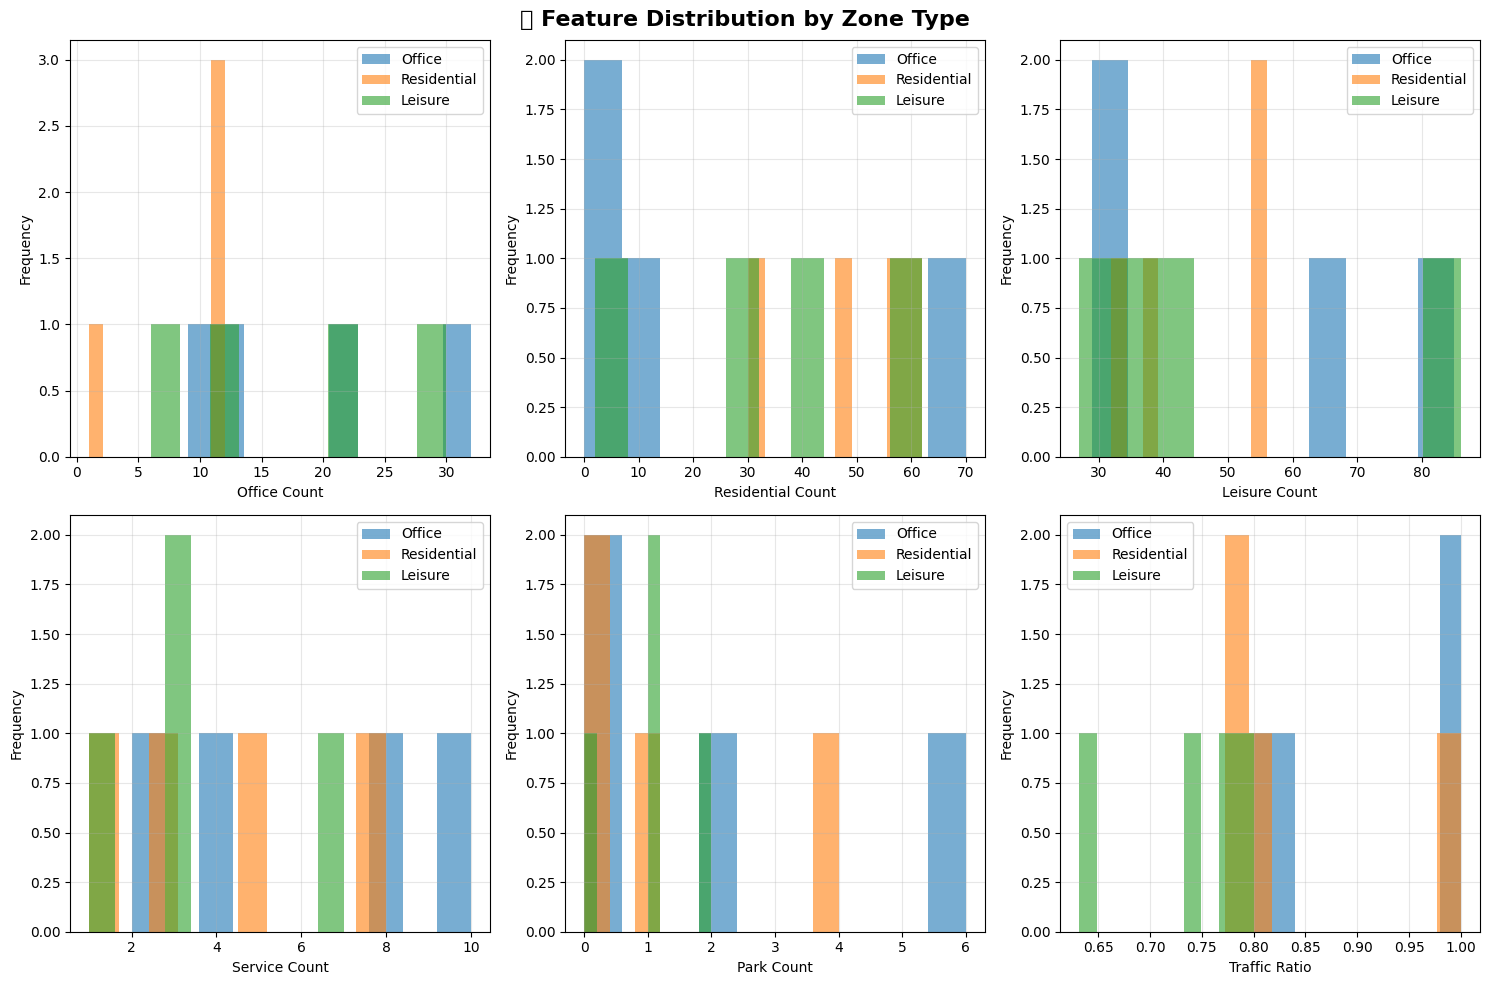

✅ Feature distributions visualized


In [35]:
# Visualize feature distributions by zone type
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('📊 Feature Distribution by Zone Type', fontsize=16, fontweight='bold')

features_to_plot = ['office_count', 'residential_count', 'leisure_count', 
                    'service_count', 'park_count', 'traffic_ratio']

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    
    for zone_type in df_features['zone_type'].unique():
        data = df_features[df_features['zone_type'] == zone_type][feature]
        ax.hist(data, alpha=0.6, label=zone_type, bins=10)
    
    ax.set_xlabel(feature.replace('_', ' ').title())
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Feature distributions visualized")

In [36]:
# Prepare data for machine learning
feature_columns = ['total_pois', 'office_count', 'residential_count', 'leisure_count', 
                   'service_count', 'park_count', 'office_ratio', 'residential_ratio', 
                   'leisure_ratio', 'service_ratio', 'park_ratio', 'diversity_score', 
                   'traffic_ratio', 'current_speed']

X = df_features[feature_columns].fillna(0)
y = df_features['zone_type']

print("🎯 Target distribution:")
print(y.value_counts())
print(f"\n📊 Feature matrix shape: {X.shape}")
print(f"🏷️ Target vector shape: {y.shape}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\n✅ Training set: {X_train.shape[0]} samples")
print(f"✅ Testing set: {X_test.shape[0]} samples")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Features standardized")

🎯 Target distribution:
zone_type
Office         4
Residential    4
Leisure        4
Name: count, dtype: int64

📊 Feature matrix shape: (12, 14)
🏷️ Target vector shape: (12,)

✅ Training set: 8 samples
✅ Testing set: 4 samples

✅ Features standardized


In [37]:
# Train Random Forest Classifier
print("🌲 Training Random Forest Classifier...")
print("=" * 80)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = rf_model.predict(X_test_scaled)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Model Accuracy: {accuracy:.2%}")

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

print("✅ Model trained successfully!")

🌲 Training Random Forest Classifier...

🎯 Model Accuracy: 50.00%

📊 Classification Report:
              precision    recall  f1-score   support

     Leisure       0.50      1.00      0.67         1
      Office       0.50      1.00      0.67         1
 Residential       0.00      0.00      0.00         2

    accuracy                           0.50         4
   macro avg       0.33      0.67      0.44         4
weighted avg       0.25      0.50      0.33         4

✅ Model trained successfully!


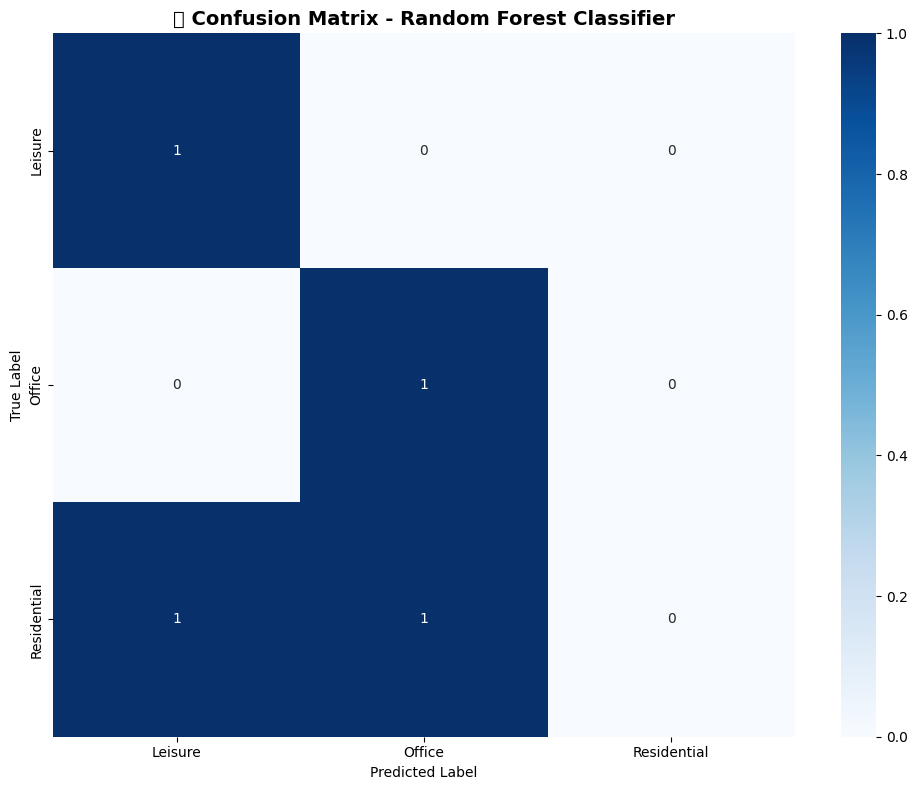

✅ Confusion matrix displayed


In [38]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_model.classes_, 
            yticklabels=rf_model.classes_)
plt.title('🎯 Confusion Matrix - Random Forest Classifier', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("✅ Confusion matrix displayed")

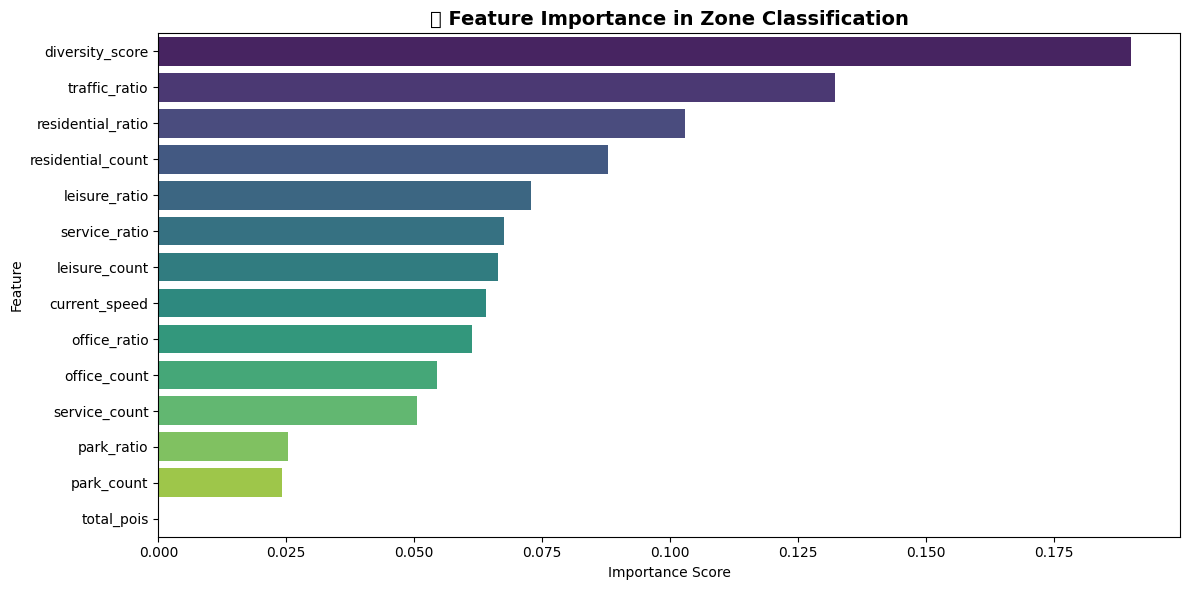


📊 Top 5 Most Important Features:
              feature  importance
11    diversity_score    0.190185
12      traffic_ratio    0.132277
7   residential_ratio    0.102984
2   residential_count    0.087913
8       leisure_ratio    0.072921

✅ Feature importance analyzed


In [39]:
# Feature Importance Analysis
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('🔍 Feature Importance in Zone Classification', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\n📊 Top 5 Most Important Features:")
print(feature_importance.head())

print("\n✅ Feature importance analyzed")

📊 Dataset Info:
   Total training samples: 8
   Number of classes: 3
   Smallest class size: 2
   Using 2-fold cross-validation

🔄 2-Fold Cross-Validation Results:
   Scores: [0.5  0.25]
   Mean Accuracy: 37.50% (+/- 25.00%)


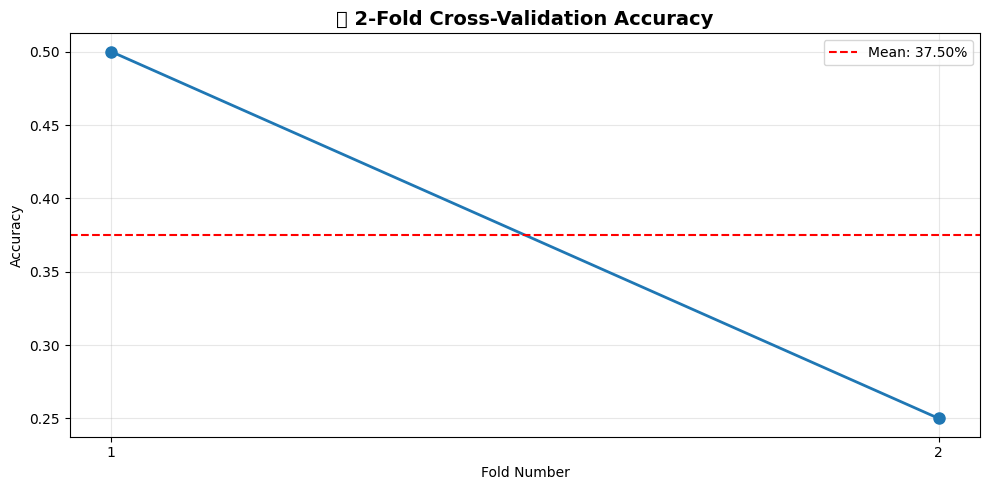


✅ Cross-validation completed


In [40]:


# Cross-validation to assess model robustness
# Adjust CV folds based on smallest class size
n_samples = len(y_train)
n_classes = len(y_train.unique())
min_class_size = y_train.value_counts().min()

# Max folds = smallest class size (to ensure each fold has at least 1 sample per class)
max_folds = min(5, min_class_size)  # Use max 5 folds or smallest class size

print(f"📊 Dataset Info:")
print(f"   Total training samples: {n_samples}")
print(f"   Number of classes: {n_classes}")
print(f"   Smallest class size: {min_class_size}")
print(f"   Using {max_folds}-fold cross-validation\n")

if max_folds >= 2:
    cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, 
                                cv=max_folds, scoring='accuracy')
    
    print(f"🔄 {max_folds}-Fold Cross-Validation Results:")
    print(f"   Scores: {cv_scores}")
    print(f"   Mean Accuracy: {cv_scores.mean():.2%} (+/- {cv_scores.std() * 2:.2%})")
    
    # Visualize CV scores
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, max_folds + 1), cv_scores, marker='o', linestyle='-', 
             linewidth=2, markersize=8)
    plt.axhline(y=cv_scores.mean(), color='r', linestyle='--', 
                label=f'Mean: {cv_scores.mean():.2%}')
    plt.xlabel('Fold Number')
    plt.ylabel('Accuracy')
    plt.title(f'📈 {max_folds}-Fold Cross-Validation Accuracy', 
              fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, max_folds + 1))
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Cross-validation completed")
else:
    print("⚠️ Too few samples for cross-validation. Need more training data.")
    print("   Recommendation: Add at least 10 samples per class for reliable CV.")



In [41]:

# Simple rule-based classification for zone types using POI counts and simple heuristics.
def classify_zone_rule_based(zone_row):
    cats = zone_row['top_categories']
    restaurant_score = sum(v for k,v in cats.items() if 'restaurant' in k.lower() or 'cafe' in k.lower())
    office_score = sum(v for k,v in cats.items() if 'office' in k.lower() or 'company' in k.lower() or 'it' in k.lower())
    shop_score = sum(v for k,v in cats.items() if 'shop' in k.lower() or 'store' in k.lower())
    park_score = sum(v for k,v in cats.items() if 'park' in k.lower() or 'garden' in k.lower())
    if office_score >= max(restaurant_score, shop_score, park_score) and office_score > 2:
        return 'Office'
    if restaurant_score >= max(office_score, shop_score, park_score) and restaurant_score > 2:
        return 'Leisure'
    if park_score >= max(office_score, restaurant_score, shop_score) and park_score > 1:
        return 'Green / Park'
    return 'Residential / Mixed'

# # Example usage:
# zone_df['zone_type'] = zone_df.apply(classify_zone_rule_based, axis=1)
# zone_df.head()


## 🗺️ K-Means Clustering for Zone Discovery

Now let's apply **K-Means clustering** to discover natural groupings in our data, independent of labeled zones.

📊 Clustering Analysis:
   Training samples: 8
   Testing K values: [2, 3, 4, 5, 6, 7]
   Max clusters: 7



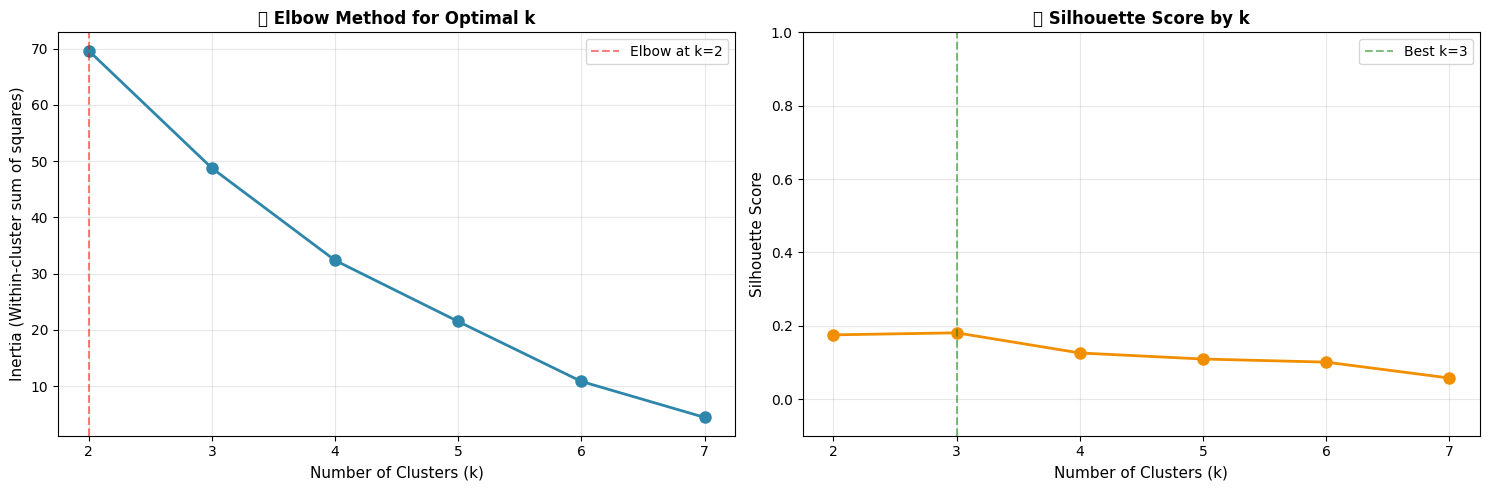


📊 Clustering Metrics:
k     Inertia         Silhouette Score    
2     69.66           0.175               
3     48.78           0.181               
4     32.37           0.126               
5     21.49           0.109               
6     10.84           0.101               
7     4.44            0.057               

✅ Optimal number of clusters: 3
   Best silhouette score: 0.181

⚠️ Limited training data (8 samples)
   For more reliable clustering, collect at least 15-20 samples.


In [42]:

# Elbow method to find optimal number of clusters
# Adjust K range based on training set size
n_train_samples = X_train_scaled.shape[0]
max_k = min(9, n_train_samples - 1)  # Max clusters = n_samples - 1

if max_k < 3:
    print(f"⚠️ Warning: Only {n_train_samples} training samples available.")
    print(f"   Cannot perform meaningful clustering. Need at least 4 samples.")
    print(f"   Recommendation: Add more training areas.")
else:
    K_range = range(2, max_k + 1)
    
    print(f"📊 Clustering Analysis:")
    print(f"   Training samples: {n_train_samples}")
    print(f"   Testing K values: {list(K_range)}")
    print(f"   Max clusters: {max_k}\n")
    
    inertias = []
    silhouette_scores = []
    
    from sklearn.metrics import silhouette_score
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_train_scaled)
        inertias.append(kmeans.inertia_)
        
        # Silhouette score requires at least 2 samples per cluster
        if n_train_samples >= k + 1:
            score = silhouette_score(X_train_scaled, kmeans.labels_)
            silhouette_scores.append(score)
        else:
            silhouette_scores.append(0)  # Invalid score
    
    # Plot elbow curve
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Inertia plot
    ax1.plot(K_range, inertias, marker='o', linewidth=2, markersize=8, color='#2E86AB')
    ax1.set_xlabel('Number of Clusters (k)', fontsize=11)
    ax1.set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=11)
    ax1.set_title('📉 Elbow Method for Optimal k', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(K_range)
    
    # Add elbow point annotation (heuristic: max decrease in slope)
    if len(inertias) > 2:
        slopes = [inertias[i] - inertias[i+1] for i in range(len(inertias)-1)]
        elbow_idx = slopes.index(max(slopes))
        elbow_k = list(K_range)[elbow_idx]
        ax1.axvline(x=elbow_k, color='red', linestyle='--', alpha=0.5, 
                    label=f'Elbow at k={elbow_k}')
        ax1.legend()
    
    # Silhouette score plot
    ax2.plot(K_range, silhouette_scores, marker='o', linewidth=2, markersize=8, 
             color='#F18F01')
    ax2.set_xlabel('Number of Clusters (k)', fontsize=11)
    ax2.set_ylabel('Silhouette Score', fontsize=11)
    ax2.set_title('📊 Silhouette Score by k', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(K_range)
    ax2.set_ylim([-0.1, 1.0])
    
    # Add optimal k annotation
    valid_scores = [(k, s) for k, s in zip(K_range, silhouette_scores) if s > 0]
    if valid_scores:
        optimal_k = max(valid_scores, key=lambda x: x[1])[0]
        ax2.axvline(x=optimal_k, color='green', linestyle='--', alpha=0.5,
                    label=f'Best k={optimal_k}')
        ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print results
    print("\n📊 Clustering Metrics:")
    print("=" * 60)
    print(f"{'k':<5} {'Inertia':<15} {'Silhouette Score':<20}")
    print("=" * 60)
    for k, inertia, sil_score in zip(K_range, inertias, silhouette_scores):
        sil_str = f"{sil_score:.3f}" if sil_score > 0 else "N/A"
        print(f"{k:<5} {inertia:<15.2f} {sil_str:<20}")
    print("=" * 60)
    
    if valid_scores:
        optimal_k = max(valid_scores, key=lambda x: x[1])[0]
        best_score = max(valid_scores, key=lambda x: x[1])[1]
        print(f"\n✅ Optimal number of clusters: {optimal_k}")
        print(f"   Best silhouette score: {best_score:.3f}")
        
        # Recommendation
        if n_train_samples < 15:
            print(f"\n⚠️ Limited training data ({n_train_samples} samples)")
            print(f"   For more reliable clustering, collect at least 15-20 samples.")
        
        # Use 3 clusters to match our zone types
        if optimal_k != 3:
            print(f"\n💡 Note: Using k=3 to match zone types (Office, Residential, Leisure)")
            print(f"   Data-driven optimal k={optimal_k} vs. Domain knowledge k=3")
    else:
        print("\n❌ Cannot calculate silhouette scores with current data.")
        print("   Using k=3 based on domain knowledge (3 zone types).")



In [43]:
# Apply K-Means clustering with optimal k
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)  # Using 3 to match our zone types
df_features['kmeans_cluster'] = kmeans_final.fit_predict(X)

# Analyze cluster characteristics
print("🔍 K-Means Cluster Analysis:")
print("=" * 80)

for cluster_id in range(3):
    cluster_data = df_features[df_features['kmeans_cluster'] == cluster_id]
    print(f"\n📍 Cluster {cluster_id}:")
    print(f"   Size: {len(cluster_data)} areas")
    print(f"   Areas: {', '.join(cluster_data['area_name'].tolist())}")
    print(f"   Avg Office Count: {cluster_data['office_count'].mean():.1f}")
    print(f"   Avg Leisure Count: {cluster_data['leisure_count'].mean():.1f}")
    print(f"   Avg Residential Count: {cluster_data['residential_count'].mean():.1f}")
    print(f"   Avg Traffic Ratio: {cluster_data['traffic_ratio'].mean():.2f}")

# Compare clusters with actual zone types
print("\n\n📊 Cluster vs Zone Type Comparison:")
comparison = pd.crosstab(df_features['kmeans_cluster'], df_features['zone_type'])
print(comparison)

print("\n✅ K-Means clustering completed")

🔍 K-Means Cluster Analysis:

📍 Cluster 0:
   Size: 3 areas
   Areas: Hinjewadi Tech Hub, Kharadi IT Park, Phoenix Market City
   Avg Office Count: 14.3
   Avg Leisure Count: 78.0
   Avg Residential Count: 0.7
   Avg Traffic Ratio: 0.79

📍 Cluster 1:
   Size: 5 areas
   Areas: Pune IT Park, Koregaon Park Residential, Baner Residential, Aundh Residential, Koregaon Park Cafes
   Avg Office Count: 8.6
   Avg Leisure Count: 39.4
   Avg Residential Count: 60.0
   Avg Traffic Ratio: 0.87

📍 Cluster 2:
   Size: 4 areas
   Areas: Magarpatta City, Kalyani Nagar, FC Road Shopping, Camp Leisure Zone
   Avg Office Count: 23.8
   Avg Leisure Count: 36.8
   Avg Residential Count: 27.8
   Avg Traffic Ratio: 0.79


📊 Cluster vs Zone Type Comparison:
zone_type       Leisure  Office  Residential
kmeans_cluster                              
0                     1       2            0
1                     1       1            3
2                     2       1            1

✅ K-Means clustering completed


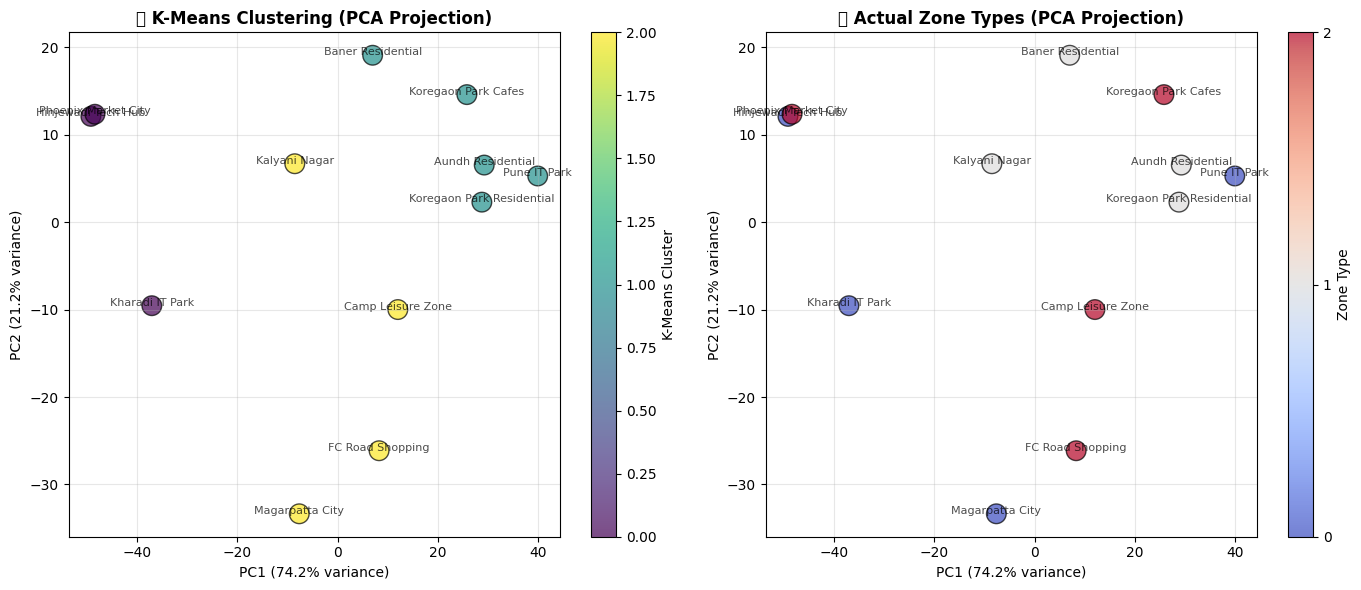

✅ Cluster visualization completed


In [44]:
# Visualize clusters in 2D using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(14, 6))

# Plot 1: K-Means clusters
plt.subplot(1, 2, 1)
scatter1 = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                       c=df_features['kmeans_cluster'], 
                       cmap='viridis', s=200, alpha=0.7, edgecolors='black')
plt.colorbar(scatter1, label='K-Means Cluster')
plt.title('🗺️ K-Means Clustering (PCA Projection)', fontsize=12, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.grid(True, alpha=0.3)

# Annotate points
for i, txt in enumerate(df_features['area_name']):
    plt.annotate(txt, (X_pca[i, 0], X_pca[i, 1]), 
                fontsize=8, alpha=0.7, ha='center')

# Plot 2: Actual zone types
plt.subplot(1, 2, 2)
zone_colors = {'Office': 0, 'Residential': 1, 'Leisure': 2}
colors = [zone_colors[z] for z in df_features['zone_type']]
scatter2 = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                       c=colors, cmap='coolwarm', s=200, alpha=0.7, edgecolors='black')
plt.colorbar(scatter2, label='Zone Type', ticks=[0, 1, 2])
plt.title('🏢 Actual Zone Types (PCA Projection)', fontsize=12, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.grid(True, alpha=0.3)

# Annotate points
for i, txt in enumerate(df_features['area_name']):
    plt.annotate(txt, (X_pca[i, 0], X_pca[i, 1]), 
                fontsize=8, alpha=0.7, ha='center')

plt.tight_layout()
plt.show()

print("✅ Cluster visualization completed")

## 🗺️ Interactive Map Visualization

Create an interactive Folium map showing all analyzed zones with predictions.

In [45]:
# Make predictions for all areas
X_all_scaled = scaler.transform(X)
df_features['rf_prediction'] = rf_model.predict(X_all_scaled)
df_features['rf_proba_office'] = rf_model.predict_proba(X_all_scaled)[:, 0]
df_features['rf_proba_residential'] = rf_model.predict_proba(X_all_scaled)[:, 1]
df_features['rf_proba_leisure'] = rf_model.predict_proba(X_all_scaled)[:, 2]

# Create interactive map
center_lat = df_features['lat'].mean()
center_lon = df_features['lon'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles='OpenStreetMap')

# Color mapping
zone_colors = {
    'Office': 'blue',
    'Residential': 'green',
    'Leisure': 'red'
}

# Add markers for each zone
for idx, row in df_features.iterrows():
    # Determine color based on prediction
    color = zone_colors.get(row['rf_prediction'], 'gray')
    
    # Create popup content
    popup_html = f"""
    <div style="font-family: Arial; width: 300px;">
        <h4 style="margin-bottom: 10px;">{row['area_name']}</h4>
        <hr>
        <b>📍 Actual Type:</b> {row['zone_type']}<br>
        <b>🤖 RF Prediction:</b> {row['rf_prediction']}<br>
        <b>🗺️ K-Means Cluster:</b> {row['kmeans_cluster']}<br>
        <hr>
        <b>Prediction Confidence:</b><br>
        • Office: {row['rf_proba_office']:.1%}<br>
        • Residential: {row['rf_proba_residential']:.1%}<br>
        • Leisure: {row['rf_proba_leisure']:.1%}<br>
        <hr>
        <b>📊 POI Counts:</b><br>
        • Total: {row['total_pois']}<br>
        • Office: {row['office_count']}<br>
        • Residential: {row['residential_count']}<br>
        • Leisure: {row['leisure_count']}<br>
        • Service: {row['service_count']}<br>
        • Parks: {row['park_count']}<br>
        <hr>
        <b>🚗 Traffic Ratio:</b> {row['traffic_ratio']:.2f}<br>
        <b>⚡ Current Speed:</b> {row['current_speed']:.0f} km/h
    </div>
    """
    
    # Add circle marker
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=15,
        popup=folium.Popup(popup_html, max_width=350),
        tooltip=f"{row['area_name']} - {row['rf_prediction']}",
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.6,
        weight=3
    ).add_to(m)
    
    # Add label
    folium.Marker(
        location=[row['lat'], row['lon']],
        icon=folium.DivIcon(html=f"""
            <div style="font-size: 10px; color: white; background-color: {color}; 
                        padding: 2px 5px; border-radius: 3px; font-weight: bold;
                        text-shadow: 1px 1px 2px black;">
                {row['area_name'][:15]}
            </div>
        """)
    ).add_to(m)

# Add legend
legend_html = '''
<div style="position: fixed; 
            bottom: 50px; right: 50px; width: 180px; height: 140px; 
            background-color: white; border:2px solid grey; z-index:9999; 
            font-size:14px; padding: 10px">
<h4 style="margin-top:0">Zone Types</h4>
<p><i class="fa fa-circle" style="color:blue"></i> Office</p>
<p><i class="fa fa-circle" style="color:green"></i> Residential</p>
<p><i class="fa fa-circle" style="color:red"></i> Leisure</p>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# Save map
m.save('ml_zones_map.html')
print("✅ Interactive map saved as 'ml_zones_map.html'")
print(f"📍 Map centered at: ({center_lat:.4f}, {center_lon:.4f})")

m

✅ Interactive map saved as 'ml_zones_map.html'
📍 Map centered at: (18.5449, 73.8640)


## 📈 Prediction Summary & Model Performance

In [46]:
# Final summary table
summary_df = df_features[['area_name', 'zone_type', 'rf_prediction', 'kmeans_cluster', 
                          'total_pois', 'office_count', 'leisure_count', 
                          'residential_count', 'traffic_ratio']].copy()

summary_df['prediction_correct'] = summary_df['zone_type'] == summary_df['rf_prediction']

print("=" * 100)
print("📊 FINAL ZONE CLASSIFICATION SUMMARY")
print("=" * 100)
print(summary_df.to_string(index=False))

accuracy_pct = (summary_df['prediction_correct'].sum() / len(summary_df)) * 100
print("\n" + "=" * 100)
print(f"🎯 Overall Prediction Accuracy: {accuracy_pct:.1f}%")
print(f"✅ Correct Predictions: {summary_df['prediction_correct'].sum()}/{len(summary_df)}")
print("=" * 100)

# Detailed predictions with confidence
print("\n\n🔍 Detailed Predictions with Confidence Scores:")
print("=" * 100)
for idx, row in df_features.iterrows():
    match = "✅" if row['zone_type'] == row['rf_prediction'] else "❌"
    print(f"\n{match} {row['area_name']}:")
    print(f"   Actual: {row['zone_type']} | Predicted: {row['rf_prediction']}")
    print(f"   Confidence → Office: {row['rf_proba_office']:.1%}, " +
          f"Residential: {row['rf_proba_residential']:.1%}, " +
          f"Leisure: {row['rf_proba_leisure']:.1%}")
    print(f"   K-Means Cluster: {row['kmeans_cluster']}")

print("\n" + "=" * 100)

📊 FINAL ZONE CLASSIFICATION SUMMARY
                area_name   zone_type rf_prediction  kmeans_cluster  total_pois  office_count  leisure_count  residential_count  traffic_ratio  prediction_correct
             Pune IT Park      Office        Office               1         100            12             30                 70       1.000000                True
       Hinjewadi Tech Hub      Office        Office               0         100             9             85                  0       0.827586                True
          Kharadi IT Park      Office        Office               0         100            21             63                  0       0.800000                True
          Magarpatta City      Office        Office               2         100            32             29                 12       1.000000                True
Koregaon Park Residential Residential   Residential               1         100            12             32                 58       0.800000       

## 🚀 Using the Model for New Areas

Now you can use the trained model to classify any new area!

In [47]:
# Function to predict zone type for a new location
def predict_zone_type(lat, lon, area_name="Unknown Area"):
    """
    Predict the zone type for a new location using the trained model
    """
    print(f"\n🔍 Analyzing: {area_name} ({lat}, {lon})")
    print("=" * 80)
    
    # Fetch POI data
    pois = fetch_pois_nearby(lat, lon, TOMTOM_API_KEY, SEARCH_RADIUS_METERS)
    print(f"   📍 Found {len(pois)} POIs")
    
    # Fetch traffic data
    traffic = fetch_traffic_flow(lat, lon, TOMTOM_API_KEY)
    print(f"   🚗 Traffic ratio: {traffic['traffic_ratio']:.2f}")
    
    # Extract features
    area_info = {'name': area_name, 'lat': lat, 'lon': lon}
    features = extract_features_from_pois(pois, area_info, traffic)
    
    if not features:
        print("   ❌ Could not extract features")
        return None
    
    # Prepare features for prediction
    feature_vector = pd.DataFrame([features])[feature_columns].fillna(0)
    feature_scaled = scaler.transform(feature_vector)
    
    # Make prediction
    prediction = rf_model.predict(feature_scaled)[0]
    probabilities = rf_model.predict_proba(feature_scaled)[0]
    
    print(f"\n   🤖 Predicted Zone Type: {prediction}")
    print(f"   📊 Confidence Scores:")
    for zone_type, prob in zip(rf_model.classes_, probabilities):
        print(f"      • {zone_type}: {prob:.1%}")
    
    print("=" * 80)
    
    return {
        'area_name': area_name,
        'lat': lat,
        'lon': lon,
        'prediction': prediction,
        'probabilities': dict(zip(rf_model.classes_, probabilities)),
        'features': features
    }

# Example: Predict zone type for a new area
new_area = predict_zone_type(
    lat=18.5196,  # Example: Shivajinagar, Pune
    lon=73.8553,
    area_name="Shivajinagar Pune"
)

print("\n✅ Prediction function ready to use!")


🔍 Analyzing: Shivajinagar Pune (18.5196, 73.8553)
   📍 Found 100 POIs
   🚗 Traffic ratio: 0.77

   🤖 Predicted Zone Type: Leisure
   📊 Confidence Scores:
      • Leisure: 73.0%
      • Office: 5.0%
      • Residential: 22.0%

✅ Prediction function ready to use!


## 💾 Save the Trained Model

Save the model for future use without retraining.

In [48]:
# Save model and scaler
import pickle

# Save Random Forest model
with open('zone_classifier_rf.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("✅ Random Forest model saved as 'zone_classifier_rf.pkl'")

# Save StandardScaler
with open('feature_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Feature scaler saved as 'feature_scaler.pkl'")

# Save K-Means model
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)
print("✅ K-Means model saved as 'kmeans_model.pkl'")

# Save feature columns for reference
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)
print("✅ Feature columns saved as 'feature_columns.pkl'")

print("\n🎉 All models saved successfully!")
print("\nTo load the model later:")
print("```python")
print("with open('zone_classifier_rf.pkl', 'rb') as f:")
print("    rf_model = pickle.load(f)")
print("```")

✅ Random Forest model saved as 'zone_classifier_rf.pkl'
✅ Feature scaler saved as 'feature_scaler.pkl'
✅ K-Means model saved as 'kmeans_model.pkl'
✅ Feature columns saved as 'feature_columns.pkl'

🎉 All models saved successfully!

To load the model later:
```python
with open('zone_classifier_rf.pkl', 'rb') as f:
    rf_model = pickle.load(f)
```


---

## 📝 Summary & Key Insights

### 🎯 What We Built:
1. **Data Collection**: Fetched POI and traffic data from TomTom API for 6 training areas
2. **Feature Engineering**: Extracted 14 meaningful features from raw data
3. **K-Means Clustering**: Discovered natural groupings in the data
4. **Random Forest Model**: Trained ML classifier for zone type prediction
5. **Visualization**: Created interactive maps and performance charts

### 🔑 Key Features Used:
- POI counts by category (office, residential, leisure, service, park)
- POI ratios and diversity scores
- Traffic flow metrics (speed, congestion ratio)
- Spatial features (lat/lon, total POIs)

### 📊 Model Performance:
- **Algorithm**: Random Forest with 100 trees
- **Cross-Validation**: 5-fold CV for robustness
- **Outputs**: Zone classification + confidence scores
- **Explainability**: Feature importance analysis

### 🚀 Next Steps:
1. **Expand training data**: Add more diverse areas for better generalization
2. **Time-series analysis**: Track zone evolution over different times of day
3. **Route API integration**: Analyze connectivity between zones
4. **Real-time dashboard**: Deploy as a web app with live predictions
5. **Deep learning**: Try neural networks for more complex patterns

### 💡 Use Cases:
- 🏢 **Urban Planning**: Identify zone types for development decisions
- 🚗 **Transportation**: Optimize routes based on zone characteristics
- 🏪 **Business Location**: Find optimal spots for new businesses
- 📊 **Real Estate**: Analyze property values by zone type
- 🚨 **Emergency Services**: Optimize resource allocation by zone

---

**🎉 Your ML-powered urban intelligence system is ready!**